# NB: UNFINISHED

# Fitting molecular energy constants
Energies of states are approximated by using polynomials, with fitted coefficients. These coefficients are historically fitted from experimental spectroscopic data. When one uses these coefficients from literature, it is important to consider the amount of transitions that were fitted, and the order of the fitted polynomial.

A common mistake of spectroscopists is using coefficients from multiple sources, or using coefficients for transitions that they were not determined for.

In this file, we demonstrate how to use a simple fitting algorithm to determine ones own coefficients using HITRAN data, which has a high amount of transitions.

# Theory
Different molecules have different formulations for their energy levels.

| Molecule | Polynomial |
|---|---|
| H2 | $\Sigma_i c_i \left( J \cdot (J + 1) \right)^n$ |
| NO | $\Sigma_i c_i \left( (J-\frac{1}{2} ) \cdot (J + \frac{3}{2}) \right)^n$ |

# Methods

We use the HITRAN database as a map from the quantum numbers of state $i$ to the energy $E_i$ of state $i$, i.e. $\left| i \right \rangle \equiv \{J_i, v_i, ...\}\ \rightarrow\ E_i$.
In the case of e.g. H2, the set of quantum numbers $\{J_i,\ v_i\}$ completely defines the state $\left| i \right \rangle$. We define the set of quantum numbers as $\{q_{j}\}_i$

We're then solving the matrix equation of the form $Ax=b$ for $x$, or
$$
\begin{pmatrix}
f_1(q_1) & f_2(q_1) & \dots & f_n(q_1) \\
f_1(q_2) & f_2(q_2) & \dots & f_n(q_2) \\
\dots \\
f_1(q_3) & f_2(q_3) & \dots & f_n(q_3)
\end{pmatrix}
\begin{pmatrix}
c_1 \\
c_2 \\
\dots \\
c_n
\end{pmatrix}
=
\begin{pmatrix}
E_1 \\
E_2 \\
\dots \\
E_n
\end{pmatrix}
$$

In [8]:
from ramlab.molecules import NO_Hitran, NO
import numpy as np
import matplotlib.pyplot as plt
import wedme.apply.dev
import lmfit

M_hitran = NO_Hitran
M_abinitio = NO

transitions = M_hitran.get_all_transitions()

Loading csv file: 308000rows [00:01, 195147.53rows/s]


Rejected 1 lines with a length not equal to 160.


# Check deviation between current implementation and HITRAN line list

<Figure size 708x500 with 0 Axes>

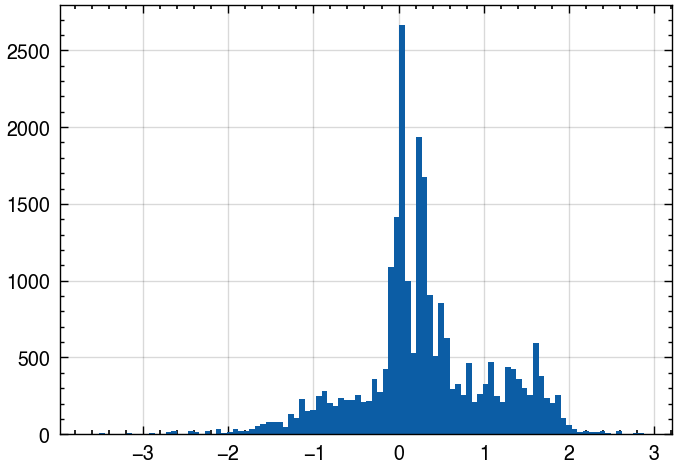

In [9]:
plt.figure()

idx = transitions.initial_E < 10e3  # Filter out high energy states. We have no desire to fit these accurately.
state_final = transitions.state_final[idx]
state_initial = transitions.state_initial[idx]

E_hitran = state_initial.E
E_ramlab = NO.E(state_initial)

plt.figure()
plt.hist(E_hitran - E_ramlab, bins=100)
plt.show()

In [5]:
def get_NO_formulae_perturbed(J, v, orders_J, orders_J_v_corr, orders_v):
    vals_E_rot_with_corr = [((J - 1 / 2) * (J + 3 / 2)) ** order_J * (v+1/2) ** order_v   for order_J in orders_J for order_v in orders_J_v_corr]
    vals_E_vib = [(v+1/2) ** order_v for order_v in orders_v]
    return [np.ones_like(J), *vals_E_rot_with_corr, *vals_E_vib]

def get_NO_formulae_perturbed_format(orders_J, orders_J_v_corr, orders_v):    
    vals_E_rot_with_corr = [f"((state.J - 1/2) * (state.J + 3/2))**{order_J} * (state.v1 + 1/2)**{order_v}"    for order_J in orders_J for order_v in orders_J_v_corr]
    vals_E_vib = [f"(state.v1 + 1/2)**{order_v}" for order_v in orders_v]

    return ["1", *vals_E_rot_with_corr, *vals_E_vib]

def print_NO_formulae(coeffs, orders_J, orders_J_v_corr, orders_v):
    vals_E_rot_with_corr = [f"((state.J - 1/2) * (state.J + 3/2))**{order_J} * (state.v1 + 1/2)**{order_v}"    for order_J in orders_J for order_v in orders_J_v_corr]
    vals_E_vib = [f"(state.v1 + 1/2)**{order_v}" for order_v in orders_v]

    n_rot_terms = len(orders_J) * len(orders_J_v_corr)

    print("\tE_vib = \\")
    for i in range(1, n_rot_terms + 1):
        print(f"\t\t{'+' if coeffs[i] > 0 else '-'} {abs(coeffs[i]):10,.3e} * {vals_E_rot_with_corr[i-1]} \\")

    print("\tE_rot = \\")
    for i in range(len(orders_v)):
        print(f"\t\t{'+' if coeffs[n_rot_terms + i] > 0 else '-'} {abs(coeffs[i]):10,.3e} * {vals_E_vib[i]} \\")

Energy for O ==  0.5 :
	E_vib = \
		-  9.488e+02 * ((state.J - 1/2) * (state.J + 3/2))**3 * (state.v1 + 1/2)**1 \
		+  1.682e+00 * ((state.J - 1/2) * (state.J + 3/2))**1 * (state.v1 + 1/2)**0 \
		-  1.743e-02 * ((state.J - 1/2) * (state.J + 3/2))**1 * (state.v1 + 1/2)**1 \
		-  2.973e-06 * ((state.J - 1/2) * (state.J + 3/2))**2 * (state.v1 + 1/2)**0 \
		+  1.002e-07 * ((state.J - 1/2) * (state.J + 3/2))**2 * (state.v1 + 1/2)**1 \
		-  1.599e-10 * ((state.J - 1/2) * (state.J + 3/2))**3 * (state.v1 + 1/2)**0 \
		-  2.798e-11 * ((state.J - 1/2) * (state.J + 3/2))**3 * (state.v1 + 1/2)**1 \
	E_rot = \
		-  9.488e+02 * (state.v1 + 1/2)**1 \
		+  1.682e+00 * (state.v1 + 1/2)**2 \
		-  1.743e-02 * (state.v1 + 1/2)**3 \
Energy for O ==  1.5 :
	E_vib = \
		-  8.286e+02 * ((state.J - 1/2) * (state.J + 3/2))**3 * (state.v1 + 1/2)**1 \
		+  1.728e+00 * ((state.J - 1/2) * (state.J + 3/2))**1 * (state.v1 + 1/2)**0 \
		-  1.783e-02 * ((state.J - 1/2) * (state.J + 3/2))**1 * (state.v1 + 1/2)**1 \
		- 

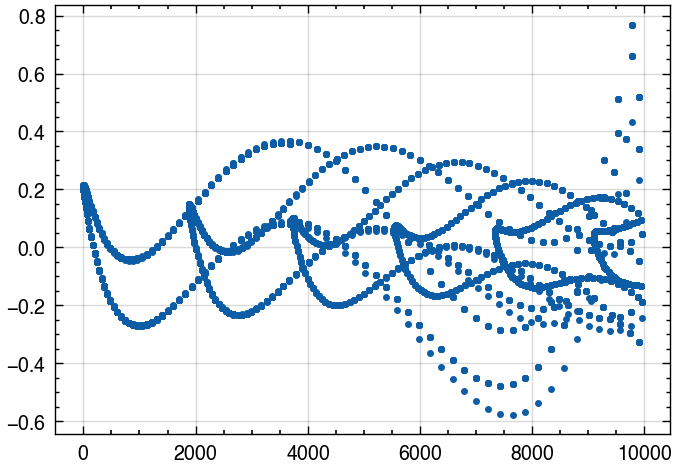

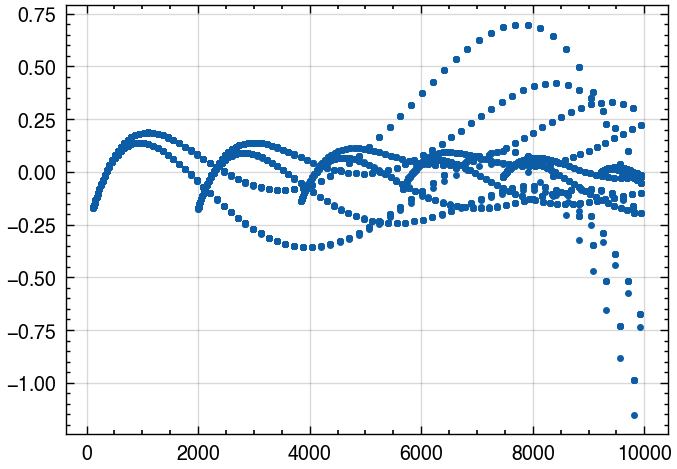

In [10]:
idx = (transitions.initial_E < 10000)

for O in np.unique(transitions.initial_O):
    idx_O = (transitions.initial_O == O) & (transitions.final_O == O)

    transitions_subset = transitions[idx & idx_O]
    # transitions_subset.final_E = transitions_subset.initial_E + transitions_subset.vacuum_wavenumber

    state_initial = transitions_subset.state_initial
    state_final = transitions_subset.state_final

    polynom_values_initial = np.array(get_NO_formulae_perturbed(state_initial.J, state_initial.v1, [1, 2, 3], [0, 1], [1, 2, 3])).T
    polynom_values_format = get_NO_formulae_perturbed_format([1, 2, 3], [0, 1], [1, 2, 3])

    E_hitran = state_initial.E
    coeffs, _, _, _ = np.linalg.lstsq(polynom_values_initial, np.array(E_hitran), rcond=None)

    E_calc = np.matmul(polynom_values_initial, coeffs) 
    dE_err = (E_hitran - E_calc) 

    print("Energy for O == ", O, ":")
    print_NO_formulae(coeffs, [1, 2, 3], [0, 1], [1, 2, 3])

    plt.figure()
    plt.plot(E_calc, dE_err, '.')

In [7]:
import wedme
wedme.apply.dev()

states = transitions.state_initial

idx_J = (states.J < 150) & (states.E > 1) & (states.E < 10000)
for v in [0]:
    idx_v = (states.v1 == v)
    for O in [1/2, 3/2]:
        idx_O = states.O == O

        states_i = states[idx_O & idx_J]
        _, idx_unique = np.unique(np.array([states_i.v1, states_i.J, states_i.O]), axis=1, return_index=True)
        states_i = states_i[idx_unique]

        E_i = states_i.E

        polynom_values = np.array(get_NO_formulae(np.ones_like(states_i.O), states_i.J, orders=[1, 2, 3])).T
        coeffs, _, _, _ = np.linalg.lstsq(polynom_values, np.array(E_i), rcond=None)

        E_polynomial = np.matmul(polynom_values, coeffs)

        E_err = E_i - E_polynomial
        E_err_rel = E_err / E_i
        E_err_rms = np.sqrt(np.mean(E_err**2))
        print(f"RMS error: {E_err_rms:.3f} cm^-1")
        print(f"Max relative error: {np.max(np.abs(E_err_rel)):.3f}")
        print(f"Max absolute error: {np.max(np.abs(E_err)):.3f}")

        print(coeffs)

        plt.figure()
        # plt.plot(states_i.J, E_i - E_polynomial, '.')
        plt.plot(states_i.J, E_i, 'o', label="Data")
        plt.plot(states_i.J, E_polynomial, label="Polynomial fit")
        plt.xlabel("J")
        plt.ylabel("Energy [$\\mathrm{cm^{-1}}$]")
        plt.title(f"v={v}, O={O}")
        plt.legend()
        plt.show()

NameError: name 'get_NO_formulae' is not defined